<a href="https://colab.research.google.com/github/BasmahFuad/ML-Final-Project-/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Acquisition and Preprocessing


In [22]:
# DATA ACQUISITION AND PREPROCESSING
# User Behavioral Anomaly Detection

# Import required libraries
import pandas as pd
import numpy as np
import glob
import os
import random
import tensorflow as tf

os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler


# STEP 1: LOAD DATASETS

# Load psychometric personality traits dataset
psychometric = pd.read_csv("psychometric.csv")

# Load user logon activity dataset
logon = pd.read_csv("logon.csv")

# Load all monthly LDAP files (18 files)
ldap_files = sorted(glob.glob("20*.csv"))

ldap_list = []

for file in ldap_files:
    temp = pd.read_csv(file)
    temp["source_month"] = file.replace(".csv", "")
    ldap_list.append(temp)

# Combine all LDAP files into one dataset
ldap = pd.concat(ldap_list, ignore_index=True)


# STEP 2: DATA CLEANING

print("Before Cleaning")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")

# Remove duplicate records
psychometric = psychometric.drop_duplicates()
logon = logon.drop_duplicates()
ldap = ldap.drop_duplicates()

# Remove rows with missing values in logon data
logon = logon.dropna()

print("\nAfter Cleaning")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")


# STEP 3: DATETIME CONVERSION

# Convert date column into datetime format
logon["date"] = pd.to_datetime(logon["date"])

# Extract useful temporal information
logon["hour"] = logon["date"].dt.hour
logon["day_of_week"] = logon["date"].dt.dayofweek
logon["month"] = logon["date"].dt.month


# STEP 4: CREATE TEMPORAL FEATURES

# Identify weekend activity: Saturday = 5, Sunday = 6
logon["is_weekend"] = (
    logon["day_of_week"].isin([5, 6])
).astype(int)

# Identify activity outside normal working hours
# Working hours assumed to be between 8 AM and 6 PM
logon["is_after_hours"] = (
    (logon["hour"] < 8) |
    (logon["hour"] > 18)
).astype(int)


# STEP 5: BEHAVIORAL FEATURE ENGINEERING

# Generate user-level behavioral statistics from logon records
logon_features = logon.groupby("user").agg(
    total_logons=("user", "count"),
    avg_logon_hour=("hour", "mean"),
    after_hours_logons=("is_after_hours", "sum"),
    weekend_logons=("is_weekend", "sum"),
    active_months=("month", "nunique")
).reset_index()

# Calculate ratio of after-hours activity
logon_features["after_hours_ratio"] = (
    logon_features["after_hours_logons"] /
    logon_features["total_logons"]
)

# Calculate ratio of weekend activity
logon_features["weekend_ratio"] = (
    logon_features["weekend_logons"] /
    logon_features["total_logons"]
)

# Rename user column for merging consistency
logon_features = logon_features.rename(
    columns={"user": "user_id"}
)


# STEP 6: LDAP FEATURE AGGREGATION

# Keep the latest organizational information for each user
ldap_features = ldap.groupby("user_id").agg({
    "role": "last",
    "business_unit": "last",
    "functional_unit": "last",
    "department": "last",
    "team": "last",
    "supervisor": "last"
}).reset_index()


# STEP 7: DATA INTEGRATION

# Merge psychometric and LDAP information
merged_data = psychometric.merge(
    ldap_features,
    on="user_id",
    how="inner"
)

# Merge logon behavioral features
merged_data = merged_data.merge(
    logon_features,
    on="user_id",
    how="inner"
)


# STEP 8: HANDLE REMAINING MISSING VALUES

# Replace missing categorical values using the most frequent value
categorical_missing = [
    "functional_unit",
    "department",
    "team",
    "supervisor"
]

for col in categorical_missing:
    merged_data[col] = merged_data[col].fillna(
        merged_data[col].mode()[0]
    )


# STEP 9: ENCODE CATEGORICAL FEATURES

# Convert text categories into numeric values
categorical_columns = [
    "employee_name",
    "user_id",
    "role",
    "functional_unit",
    "department",
    "team",
    "supervisor"
]

for col in categorical_columns:
    le = LabelEncoder()
    merged_data[col] = le.fit_transform(
        merged_data[col].astype(str)
    )


# STEP 10: PREPARE MODEL INPUT DATA

# Remove identifiers that should not be used during model training
model_data = merged_data.drop(
    columns=["employee_name", "user_id"]
)

print("\nModel Data Shape")
print(model_data.shape)

# ==========================================================
# RULE-BASED PSEUDO-LABEL GENERATION
# ==========================================================

pseudo_data = model_data.copy()

# Define rule thresholds using percentiles from the dataset
high_logon_threshold = pseudo_data["total_logons"].quantile(0.90)
high_after_hours_threshold = pseudo_data["after_hours_ratio"].quantile(0.90)
high_weekend_threshold = pseudo_data["weekend_ratio"].quantile(0.90)

# Create risk score based on independent behavioral rules
pseudo_data["risk_score"] = 0

pseudo_data["risk_score"] += (
    pseudo_data["total_logons"] >= high_logon_threshold
).astype(int)

pseudo_data["risk_score"] += (
    pseudo_data["after_hours_ratio"] >= high_after_hours_threshold
).astype(int)

pseudo_data["risk_score"] += (
    pseudo_data["weekend_ratio"] >= high_weekend_threshold
).astype(int)

# Assign pseudo-label
# 1 = Anomaly, 0 = Normal
pseudo_data["pseudo_label"] = np.where(
    pseudo_data["risk_score"] >= 2,
    1,
    0
)

print("Pseudo-label distribution:")
print(pseudo_data["pseudo_label"].value_counts())

# Save pseudo-labeled dataset
pseudo_data.to_csv("pseudo_labeled_user_behavior.csv", index=False)


# STEP 11: FEATURE SCALING

# Standardize all features to mean = 0 and standard deviation = 1
scaler = StandardScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(model_data),
    columns=model_data.columns
)


# STEP 12: SAVE PROCESSED DATASETS

# Save merged dataset with identifiers for later user mapping
merged_data.to_csv(
    "merged_user_behavior_with_ids.csv",
    index=False
)

# Save cleaned dataset before scaling
model_data.to_csv(
    "model_data.csv",
    index=False
)

# Save final scaled dataset used for ML models
scaled_data.to_csv(
    "preprocessed_user_behavior.csv",
    index=False
)


# STEP 13: PREPROCESSING SUMMARY

print("=" * 60)
print("DATA ACQUISITION AND PREPROCESSING SUMMARY")
print("=" * 60)

print("\nOriginal Datasets")
print(f"Psychometric Shape: {psychometric.shape}")
print(f"Logon Shape: {logon.shape}")
print(f"LDAP Shape: {ldap.shape}")

print("\nLDAP Files Loaded")
print(f"Number of LDAP Files: {len(ldap_files)}")

print("\nMerged Dataset")
print(f"Merged Shape: {merged_data.shape}")

print("\nData Quality Checks")
print(f"Total Missing Values: {merged_data.isnull().sum().sum()}")
print(f"Duplicate Rows: {merged_data.duplicated().sum()}")

print("\nFinal Modeling Dataset")
print(f"Scaled Data Shape: {scaled_data.shape}")
print(f"Number of Users: {scaled_data.shape[0]}")
print(f"Number of Features: {scaled_data.shape[1]}")

print("\nBehavioral Features Generated")
print("- total_logons")
print("- avg_logon_hour")
print("- after_hours_logons")
print("- weekend_logons")
print("- active_months")
print("- after_hours_ratio")
print("- weekend_ratio")

print("\nPreview of Final Dataset")
display(scaled_data.head())

print("\nFiles Saved Successfully")
print("1. merged_user_behavior_with_ids.csv")
print("2. model_data.csv")
print("3. preprocessed_user_behavior.csv")

print("\nPreprocessing Completed Successfully")
print("=" * 60)
# Save pseudo-labeled dataset
pseudo_data.to_csv("pseudo_labeled_user_behavior.csv", index=False)
model_data["pseudo_label"] = pseudo_data["pseudo_label"]

print(model_data.columns.tolist())
print(model_data["pseudo_label"].value_counts())

Before Cleaning
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 5)
LDAP Shape: (68923, 11)

After Cleaning
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 5)
LDAP Shape: (68923, 11)

Model Data Shape
(4000, 18)
Pseudo-label distribution:
pseudo_label
0    3685
1     315
Name: count, dtype: int64
DATA ACQUISITION AND PREPROCESSING SUMMARY

Original Datasets
Psychometric Shape: (4000, 7)
Logon Shape: (3530285, 10)
LDAP Shape: (68923, 11)

LDAP Files Loaded
Number of LDAP Files: 18

Merged Dataset
Merged Shape: (4000, 20)

Data Quality Checks
Total Missing Values: 0
Duplicate Rows: 0

Final Modeling Dataset
Scaled Data Shape: (4000, 18)
Number of Users: 4000
Number of Features: 18

Behavioral Features Generated
- total_logons
- avg_logon_hour
- after_hours_logons
- weekend_logons
- active_months
- after_hours_ratio
- weekend_ratio

Preview of Final Dataset


,O,C,E,A,N,role,business_unit,functional_unit,department,team,supervisor,total_logons,avg_logon_hour,after_hours_logons,weekend_logons,active_months,after_hours_ratio,weekend_ratio
0,0.078081,0.718616,0.810750,0.627225,-1.722926,-0.815592,0.0,-1.717848,1.703985,1.686898,0.244375,5.467969,-0.680513,5.688960,-0.278389,0.212012,1.622154,-0.301805
1,0.267770,0.718616,-1.434721,-0.913534,-0.514703,0.152374,0.0,0.264894,-0.793713,0.320483,0.344513,0.253961,-0.654917,0.128940,-0.278389,0.212012,0.098297,-0.301805
2,-0.585831,-1.561258,1.349663,-0.641635,0.894891,0.152374,0.0,0.661443,-0.793713,-0.811689,-0.327840,-0.414813,0.482927,-0.856808,-0.278389,0.212012,-1.295533,-0.301805
3,0.172925,1.630566,-0.626352,1.442921,-0.313333,0.152374,0.0,0.661443,-0.793713,1.569776,-0.871445,0.253961,0.072848,-0.293041,-0.278389,0.212012,-0.498377,-0.301805
4,-1.723964,-1.470063,1.080206,0.899123,-0.514703,-0.250945,0.0,-0.528202,0.871419,-0.694568,-0.699780,-0.414813,-0.218542,0.344994,-0.278389,0.212012,1.060135,-0.301805



Files Saved Successfully
1. merged_user_behavior_with_ids.csv
2. model_data.csv
3. preprocessed_user_behavior.csv

Preprocessing Completed Successfully
['O', 'C', 'E', 'A', 'N', 'role', 'business_unit', 'functional_unit', 'department', 'team', 'supervisor', 'total_logons', 'avg_logon_hour', 'after_hours_logons', 'weekend_logons', 'active_months', 'after_hours_ratio', 'weekend_ratio', 'pseudo_label']
pseudo_label
0    3685
1     315
Name: count, dtype: int64


**Data Split**

In [23]:

from sklearn.model_selection import train_test_split
print(model_data.columns.tolist())
# ==========================================================
# FEATURE SELECTION EXPERIMENT SETUP
# ==========================================================

all_features = model_data.drop("pseudo_label", axis=1).columns.tolist()

# Rank features by absolute correlation with pseudo_label
correlations = model_data[all_features + ["pseudo_label"]].corr(numeric_only=True)["pseudo_label"].abs()
correlations = correlations.drop("pseudo_label")

ranked_features = correlations.sort_values(ascending=False).index.tolist()

print("Ranked Features:")
print(ranked_features)

# Choose number of features for this experiment: 18, 9, 4, 2, or 1
num_features = 4   #best

selected_features = ranked_features[:num_features]

print("\nSelected Features:")
print(selected_features)
print("Number of Selected Features:", len(selected_features))

X = model_data[selected_features]
y = model_data["pseudo_label"]

scaler = StandardScaler()

scaled_data = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

X_tabular = scaled_data.values

X_train_tabular, X_test_tabular, y_train, y_test = train_test_split(
    X_tabular,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("=" * 60)
print("DATASET PARTITIONING COMPLETE (80/20 SPLIT)")
print("=" * 60)
print(f"Training Data: {X_train_tabular.shape}")
print(f"Testing Data : {X_test_tabular.shape}")
print("Test Label Distribution:")
print(y_test.value_counts())

['O', 'C', 'E', 'A', 'N', 'role', 'business_unit', 'functional_unit', 'department', 'team', 'supervisor', 'total_logons', 'avg_logon_hour', 'after_hours_logons', 'weekend_logons', 'active_months', 'after_hours_ratio', 'weekend_ratio', 'pseudo_label']
Ranked Features:
['total_logons', 'weekend_logons', 'weekend_ratio', 'after_hours_logons', 'after_hours_ratio', 'functional_unit', 'department', 'role', 'avg_logon_hour', 'active_months', 'team', 'N', 'C', 'E', 'supervisor', 'A', 'O', 'business_unit']

Selected Features:
['total_logons', 'weekend_logons', 'weekend_ratio', 'after_hours_logons']
Number of Selected Features: 4
DATASET PARTITIONING COMPLETE (80/20 SPLIT)
Training Data: (3200, 4)
Testing Data : (800, 4)
Test Label Distribution:
pseudo_label
0    737
1     63
Name: count, dtype: int64


**LSTM Autoencoder Model Development and Training**

STARTING SEARCH STAGE FOR OPTIMAL PARAMETER
Searching Latent Dimensions: Testing 16 Hidden Units...
Searching Latent Dimensions: Testing 32 Hidden Units...
Searching Latent Dimensions: Testing 64 Hidden Units...


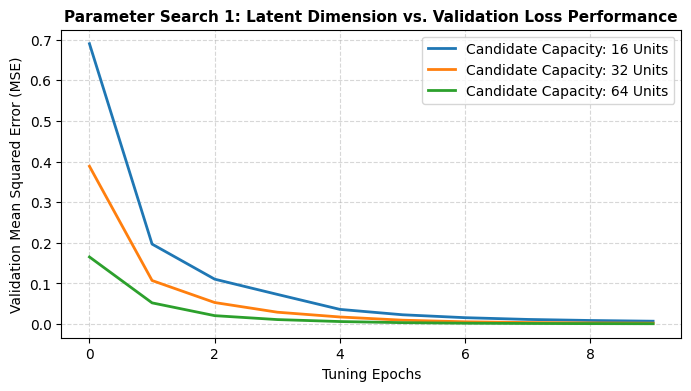

Searching Learning Rates: Testing rate of 0.01...
Searching Learning Rates: Testing rate of 0.001...
Searching Learning Rates: Testing rate of 0.0001...


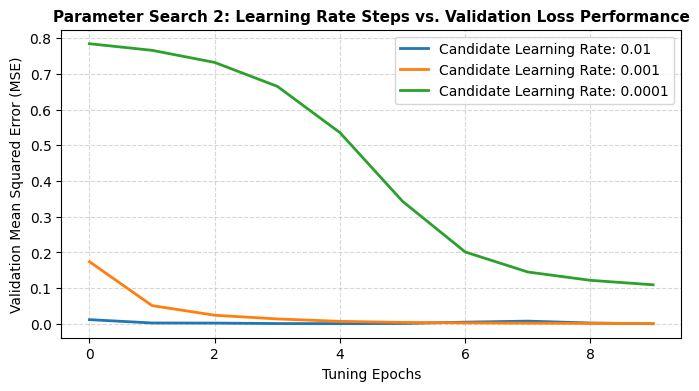

Searching Batch Sizes: Testing size of 16...
Searching Batch Sizes: Testing size of 32...
Searching Batch Sizes: Testing size of 64...


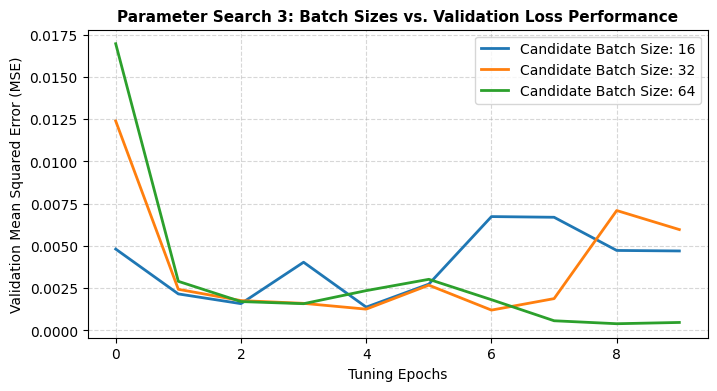


TRAINING FINAL SPECIFICATION USING CALCULATED OPTIMAL VALUES
Epoch 1/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.2699 - val_loss: 0.0257
Epoch 2/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0205 - val_loss: 0.0046
Epoch 3/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0035 - val_loss: 0.0019
Epoch 4/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0025 - val_loss: 0.0020
Epoch 5/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0032 - val_loss: 0.0019
Epoch 6/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0042 - val_loss: 0.0025
Epoch 7/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0039 - val_loss: 0.0020
Epoch 8/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 9/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0023 - val_loss: 0.0013
Epoch 10/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0026 - val_loss: 0.0014
Epoch 11/40
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0020 - val_loss: 8.8490e-04
Epoch 1

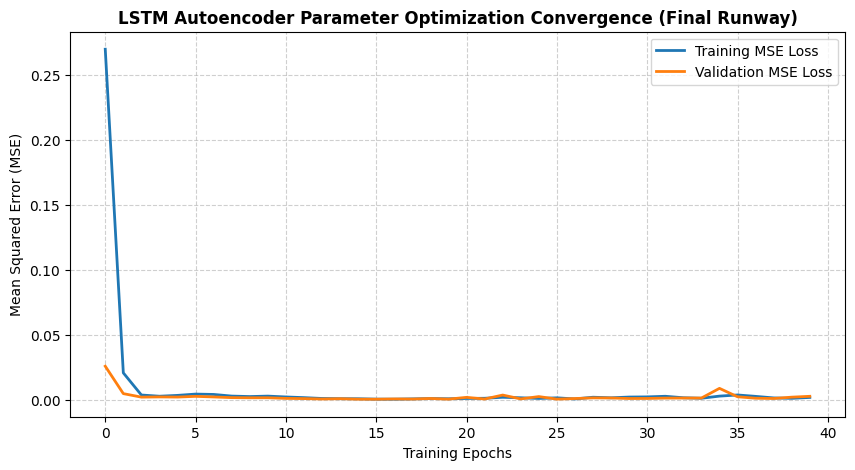

TRAINING STATUS: Complete. Model saved as 'lstm_autoencoder_trained.keras'

Optimum parameters for the proposed LSTM Autoencoder Model
Parameters             | Optimal Value Chosen
--------------------------------------------------
Optimization Algorithm | Adam
Learning Rate          | 0.009999999776482582
Batch Size             | 64
Training Epochs        | 40
Latent Dimension       | 64 Hidden Units
Loss Function          | MSE
--------------------------------------------------


In [24]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, RepeatVector, TimeDistributed, Dense
import matplotlib.pyplot as plt

# 1. Reshape 2D training data into 3D tensor for LSTM input (samples, time_steps, features)
X_train_seq = np.reshape(X_train_tabular, (X_train_tabular.shape[0], 1, X_train_tabular.shape[1]))

TIME_STEPS = X_train_seq.shape[1]
NUM_FEATURES = X_train_seq.shape[2]

print("=" * 60)
print("STARTING SEARCH STAGE FOR OPTIMAL PARAMETER")
print("=" * 60)

# =====================================================================
# SEARCH FOR PARAMETER 1: LATENT DIMENSION (CAPACITY SELECTION)
# =====================================================================
latent_options = [16, 32, 64]
latent_search_histories = {}

for units in latent_options:
    print(f"Searching Latent Dimensions: Testing {units} Hidden Units...")
    test_model = Sequential([
        Input(shape=(TIME_STEPS, NUM_FEATURES)),
        LSTM(units, activation='relu', return_sequences=False),
        RepeatVector(TIME_STEPS),
        LSTM(units, activation='relu', return_sequences=True),
        TimeDistributed(Dense(NUM_FEATURES))
    ])
    test_model.compile(optimizer='adam', loss='mse')
    # Use a shorter training window to evaluate performance shifts
    history_search = test_model.fit(X_train_seq, X_train_seq, epochs=10, batch_size=32, validation_split=0.1, shuffle=True, verbose=0)
    latent_search_histories[units] = history_search.history['val_loss']

# Plot 1: Performance change while searching Latent Dimensions
plt.figure(figsize=(8, 4))
for units in latent_options:
    plt.plot(latent_search_histories[units], linewidth=2, label=f'Candidate Capacity: {units} Units')
plt.title('Parameter Search 1: Latent Dimension vs. Validation Loss Performance', fontsize=11, fontweight='bold')
plt.xlabel('Tuning Epochs')
plt.ylabel('Validation Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Programmatically pick the best dimension based on lowest final validation loss
optimal_latent_dim = min(latent_search_histories, key=lambda k: latent_search_histories[k][-1])


# =====================================================================
# SEARCH FOR PARAMETER 2: LEARNING RATE SELECTION
# =====================================================================
lr_options = [0.01, 0.001, 0.0001]
lr_search_histories = {}

for lr in lr_options:
    print(f"Searching Learning Rates: Testing rate of {lr}...")
    test_model = Sequential([
        Input(shape=(TIME_STEPS, NUM_FEATURES)),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=False),
        RepeatVector(TIME_STEPS),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=True),
        TimeDistributed(Dense(NUM_FEATURES))
    ])
    test_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    history_search = test_model.fit(X_train_seq, X_train_seq, epochs=10, batch_size=32, validation_split=0.1, shuffle=True, verbose=0)
    lr_search_histories[lr] = history_search.history['val_loss']

# Plot 2: Performance change while searching Learning Rates
plt.figure(figsize=(8, 4))
for lr in lr_options:
    plt.plot(lr_search_histories[lr], linewidth=2, label=f'Candidate Learning Rate: {lr}')
plt.title('Parameter Search 2: Learning Rate Steps vs. Validation Loss Performance', fontsize=11, fontweight='bold')
plt.xlabel('Tuning Epochs')
plt.ylabel('Validation Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Programmatically pick the best learning rate based on lowest final validation loss
optimal_lr = min(lr_search_histories, key=lambda k: lr_search_histories[k][-1])


# =====================================================================
# SEARCH FOR PARAMETER 3: BATCH SIZE SELECTION
# =====================================================================
batch_options = [16, 32, 64]
batch_search_histories = {}

for bs in batch_options:
    print(f"Searching Batch Sizes: Testing size of {bs}...")
    test_model = Sequential([
        Input(shape=(TIME_STEPS, NUM_FEATURES)),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=False),
        RepeatVector(TIME_STEPS),
        LSTM(optimal_latent_dim, activation='relu', return_sequences=True),
        TimeDistributed(Dense(NUM_FEATURES))
    ])
    test_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=optimal_lr), loss='mse')
    history_search = test_model.fit(X_train_seq, X_train_seq, epochs=10, batch_size=bs, validation_split=0.1, shuffle=True, verbose=0)
    batch_search_histories[bs] = history_search.history['val_loss']

# Plot 3: Performance change while searching Batch Sizes
plt.figure(figsize=(8, 4))
for bs in batch_options:
    plt.plot(batch_search_histories[bs], linewidth=2, label=f'Candidate Batch Size: {bs}')
plt.title('Parameter Search 3: Batch Sizes vs. Validation Loss Performance', fontsize=11, fontweight='bold')
plt.xlabel('Tuning Epochs')
plt.ylabel('Validation Mean Squared Error (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Programmatically pick the best batch size based on lowest final validation loss
optimal_batch_size = min(batch_search_histories, key=lambda k: batch_search_histories[k][-1])


# =====================================================================
# FINAL DEPLOYMENT STAGE: TRAIN FINAL MODEL WITH CALCULATED BEST PARAMETERS
# =====================================================================
print("\n" + "="*60)
print(f"TRAINING FINAL SPECIFICATION USING CALCULATED OPTIMAL VALUES")
print("="*60)

# Define LSTM Autoencoder network architecture using the calculated winners
model = Sequential([
    Input(shape=(TIME_STEPS, NUM_FEATURES)),
    LSTM(optimal_latent_dim, activation='relu', return_sequences=False),
    RepeatVector(TIME_STEPS),
    LSTM(optimal_latent_dim, activation='relu', return_sequences=True),
    TimeDistributed(Dense(NUM_FEATURES))
])

# Compile model using calculated optimal learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=optimal_lr), loss='mse')

# Train the final model configuration on the preprocessed training dataset over full 40 epochs
history = model.fit(
    X_train_seq, X_train_seq,
    epochs=40,
    batch_size=optimal_batch_size,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

# Plot 4: Final Convergence Verification
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], linewidth=2, label='Training MSE Loss')
plt.plot(history.history['val_loss'], linewidth=2, label='Validation MSE Loss')
plt.title('LSTM Autoencoder Parameter Optimization Convergence (Final Runway)', fontsize=12, fontweight='bold')
plt.xlabel('Training Epochs', fontsize=10)
plt.ylabel('Mean Squared Error (MSE)', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Export the trained model state to a native Keras file
model.save('lstm_autoencoder_trained.keras')

print("=" * 60)
print("TRAINING STATUS: Complete. Model saved as 'lstm_autoencoder_trained.keras'")
print("=" * 60)


# =====================================================================
# DYNAMIC PARAMETER EXTRACTION FOR SECTION 5.4 TABLE
# =====================================================================
extracted_optimizer_name = model.optimizer.__class__.__name__
extracted_learning_rate = model.optimizer.learning_rate.numpy()
extracted_epochs = len(history.epoch)
extracted_batch_size = history.params.get('batch_size', optimal_batch_size)
extracted_latent_dim = model.layers[0].units
extracted_loss_function = model.loss if isinstance(model.loss, str) else model.loss.__name__

# Print the dynamically calculated parameters table
print("\n" + "="*60)
print("Optimum parameters for the proposed LSTM Autoencoder Model")
print("="*60)
print(f"Parameters             | Optimal Value Chosen")
print(f"--------------------------------------------------")
print(f"Optimization Algorithm | {extracted_optimizer_name}")
print(f"Learning Rate          | {extracted_learning_rate}")
print(f"Batch Size             | {extracted_batch_size}")
print(f"Training Epochs        | {extracted_epochs}")
print(f"Latent Dimension       | {extracted_latent_dim} Hidden Units")
print(f"Loss Function          | {extracted_loss_function.upper()}")
print(f"--------------------------------------------------")

**Isolation Forest Model Development and Training**

ISOLATION FOREST PARAMETER OPTIMIZATION


,n_estimators,contamination,max_samples,max_features,accuracy,precision,recall,f1_score,anomalies_detected,average_anomaly_score
74,100,0.08,auto,1.00,0.97500,0.841270,0.841270,0.841270,63,0.221379
126,200,0.10,auto,0.50,0.97250,0.773333,0.920635,0.840580,75,0.194530
127,200,0.10,auto,0.75,0.97125,0.770270,0.904762,0.832117,74,0.201348
119,200,0.08,auto,1.00,0.97375,0.850000,0.809524,0.829268,60,0.224172
82,100,0.10,auto,0.75,0.97000,0.760000,0.904762,0.826087,75,0.209279
128,200,0.10,auto,1.00,0.97000,0.760000,0.904762,0.826087,75,0.207697
38,50,0.10,auto,1.00,0.97000,0.760000,0.904762,0.826087,75,0.201797
83,100,0.10,auto,1.00,0.97000,0.767123,0.888889,0.823529,73,0.202944
29,50,0.08,auto,1.00,0.97000,0.800000,0.825397,0.812500,65,0.220225
118,200,0.08,auto,0.75,0.96875,0.816667,0.777778,0.796748,60,0.214684



Selected Best Parameters Automatically
n_estimators: 100
contamination: 0.08
max_samples: auto
max_features: 1.0
Best F1-score: 0.8413

ISOLATION FOREST MODEL DEVELOPMENT AND TRAINING
Model Used: Isolation Forest
Training Data Shape: (3200, 4)
Testing Data Shape: (800, 4)
Number of Trees: 100
Contamination Rate: 0.08
Max Samples: auto
Max Features: 1.0

Testing Prediction Summary
anomaly_label
Normal     737
Anomaly     63
Name: count, dtype: int64

Preview of Isolation Forest Results


,anomaly_score,prediction,anomaly_label
0,-0.036450,-1,Anomaly
1,0.279534,1,Normal
2,0.282558,1,Normal
3,0.146095,1,Normal
4,0.275239,1,Normal


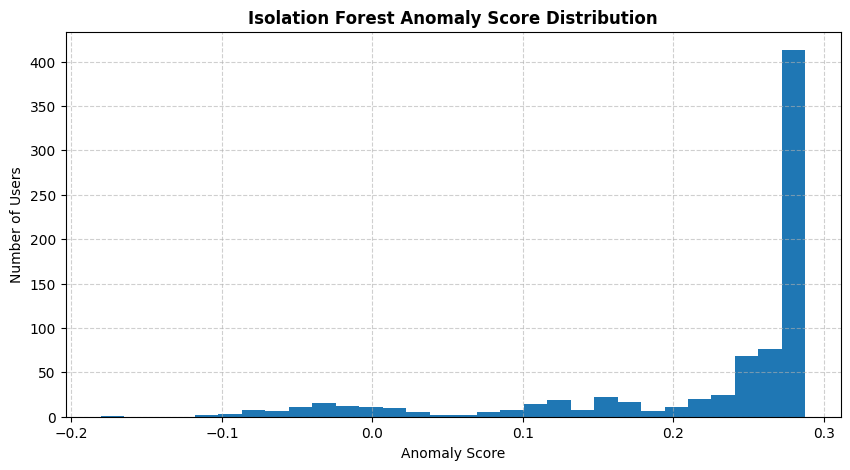

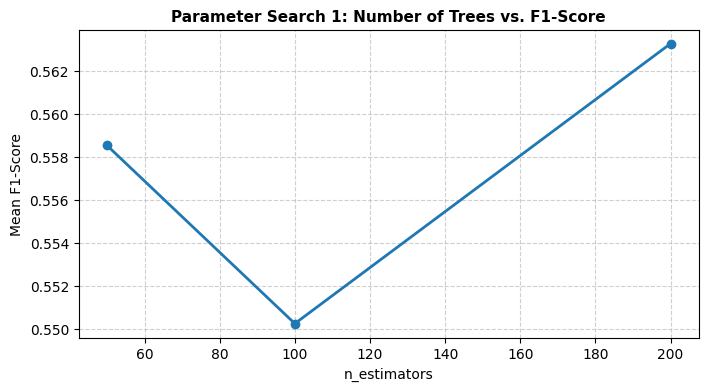

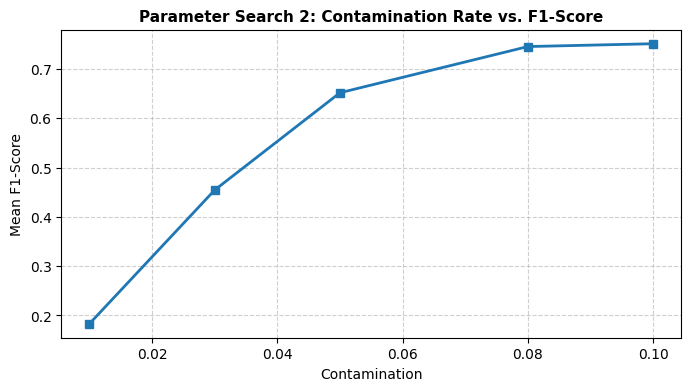

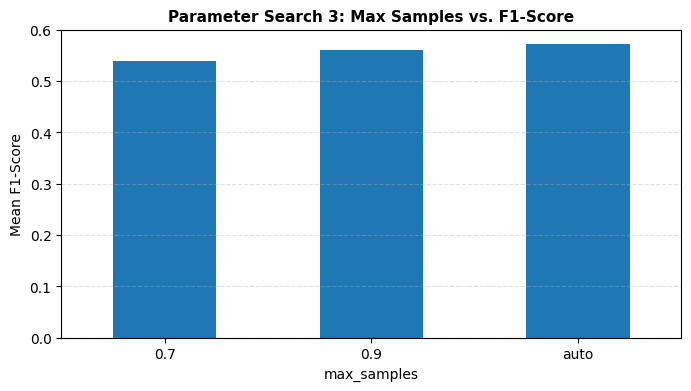

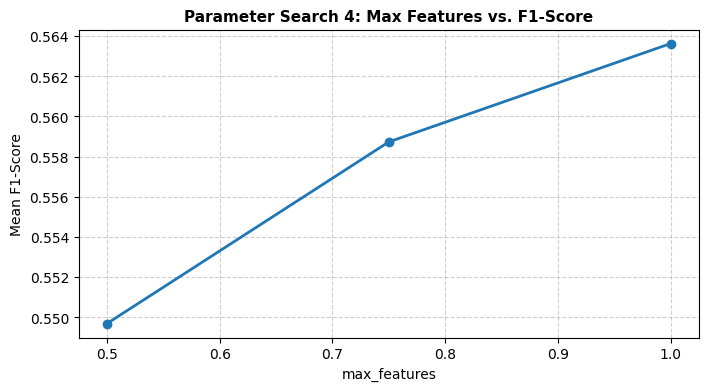


Files Saved Successfully
1. isolation_forest_parameter_optimization.csv
2. isolation_forest_results.csv

Optimum Parameters for the Proposed Isolation Forest Model
Parameters             | Optimal Value Chosen
--------------------------------------------------
n_estimators           | 100
contamination          | 0.08
max_samples            | auto
max_features           | 1.0
random_state           | 42
--------------------------------------------------


In [25]:
# ==========================================================
# Isolation Forest Model Development and Training
# ==========================================================

from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================================
# 1. PARAMETER OPTIMIZATION SETTINGS
# ==========================================================

n_estimators_values = [50, 100, 200]
contamination_values = [0.01, 0.03, 0.05, 0.08, 0.10]
max_samples_values = ["auto", 0.7, 0.9]
max_features_values = [0.5, 0.75, 1.0]

optimization_results = []

# ==========================================================
# 2. TRY DIFFERENT PARAMETER COMBINATIONS
# ==========================================================

for n_estimators in n_estimators_values:
    for contamination in contamination_values:
        for max_samples in max_samples_values:
            for max_features in max_features_values:

                temp_model = IsolationForest(
                    n_estimators=n_estimators,
                    contamination=contamination,
                    max_samples=max_samples,
                    max_features=max_features,
                    random_state=42
                )

                temp_model.fit(X_train_tabular)

                test_predictions = temp_model.predict(X_test_tabular)
                test_scores = temp_model.decision_function(X_test_tabular)

                y_pred_temp = np.where(test_predictions == -1, 1, 0)

                accuracy = accuracy_score(y_test, y_pred_temp)
                precision = precision_score(y_test, y_pred_temp, zero_division=0)
                recall = recall_score(y_test, y_pred_temp, zero_division=0)
                f1 = f1_score(y_test, y_pred_temp, zero_division=0)

                optimization_results.append({
                    "n_estimators": n_estimators,
                    "contamination": contamination,
                    "max_samples": max_samples,
                    "max_features": max_features,
                    "accuracy": accuracy,
                    "precision": precision,
                    "recall": recall,
                    "f1_score": f1,
                    "anomalies_detected": y_pred_temp.sum(),
                    "average_anomaly_score": test_scores.mean()
                })

# ==========================================================
# 3. CONVERT OPTIMIZATION RESULTS TO DATAFRAME
# ==========================================================

optimization_results_df = pd.DataFrame(optimization_results)

print("=" * 60)
print("ISOLATION FOREST PARAMETER OPTIMIZATION")
print("=" * 60)

display(
    optimization_results_df.sort_values(
        by="f1_score",
        ascending=False
    ).head(10)
)

# ==========================================================
# 4. SELECT BEST PARAMETERS AUTOMATICALLY
# ==========================================================

best_row = optimization_results_df.sort_values(
    by="f1_score",
    ascending=False
).iloc[0]

best_n_estimators = int(best_row["n_estimators"])
best_contamination = float(best_row["contamination"])
best_max_samples = best_row["max_samples"]
best_max_features = float(best_row["max_features"])

print("\nSelected Best Parameters Automatically")
print(f"n_estimators: {best_n_estimators}")
print(f"contamination: {best_contamination}")
print(f"max_samples: {best_max_samples}")
print(f"max_features: {best_max_features}")
print(f"Best F1-score: {best_row['f1_score']:.4f}")

# ==========================================================
# 5. TRAIN FINAL ISOLATION FOREST MODEL
# ==========================================================

isolation_forest = IsolationForest(
    n_estimators=best_n_estimators,
    contamination=best_contamination,
    max_samples=best_max_samples,
    max_features=best_max_features,
    random_state=42
)

isolation_forest.fit(X_train_tabular)

# ==========================================================
# 6. PREDICT ANOMALIES
# ==========================================================

train_if_predictions = isolation_forest.predict(X_train_tabular)
test_if_predictions = isolation_forest.predict(X_test_tabular)

# ==========================================================
# 7. CALCULATE ANOMALY SCORES
# ==========================================================

train_if_scores = isolation_forest.decision_function(X_train_tabular)
test_if_scores = isolation_forest.decision_function(X_test_tabular)

# ==========================================================
# 8. CONVERT PREDICTIONS INTO READABLE LABELS
# ==========================================================

test_if_labels = np.where(test_if_predictions == -1, "Anomaly", "Normal")
y_pred_if = np.where(test_if_predictions == -1, 1, 0)

# ==========================================================
# 9. CREATE RESULTS DATAFRAME
# ==========================================================

isolation_forest_results = pd.DataFrame({
    "anomaly_score": test_if_scores,
    "prediction": test_if_predictions,
    "anomaly_label": test_if_labels
})

print("\n" + "=" * 60)
print("ISOLATION FOREST MODEL DEVELOPMENT AND TRAINING")
print("=" * 60)
print("Model Used: Isolation Forest")
print(f"Training Data Shape: {X_train_tabular.shape}")
print(f"Testing Data Shape: {X_test_tabular.shape}")
print(f"Number of Trees: {isolation_forest.n_estimators}")
print(f"Contamination Rate: {isolation_forest.contamination}")
print(f"Max Samples: {isolation_forest.max_samples}")
print(f"Max Features: {isolation_forest.max_features}")

print("\nTesting Prediction Summary")
print(isolation_forest_results["anomaly_label"].value_counts())

print("\nPreview of Isolation Forest Results")
display(isolation_forest_results.head())

# ==========================================================
# 10. PLOT ANOMALY SCORE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10, 5))
plt.hist(test_if_scores, bins=30)
plt.title("Isolation Forest Anomaly Score Distribution", fontsize=12, fontweight="bold")
plt.xlabel("Anomaly Score")
plt.ylabel("Number of Users")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ==========================================================
# 11. PARAMETER SEARCH PLOTS
# ==========================================================

plot_df = optimization_results_df.copy()
plot_df["max_samples"] = plot_df["max_samples"].astype(str)

plt.figure(figsize=(8, 4))
plot_df.groupby("n_estimators")["f1_score"].mean().plot(marker="o", linewidth=2)
plt.title("Parameter Search 1: Number of Trees vs. F1-Score", fontsize=11, fontweight="bold")
plt.xlabel("n_estimators")
plt.ylabel("Mean F1-Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(8, 4))
plot_df.groupby("contamination")["f1_score"].mean().plot(marker="s", linewidth=2)
plt.title("Parameter Search 2: Contamination Rate vs. F1-Score", fontsize=11, fontweight="bold")
plt.xlabel("Contamination")
plt.ylabel("Mean F1-Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(8, 4))
plot_df.groupby("max_samples")["f1_score"].mean().plot(kind="bar")
plt.title("Parameter Search 3: Max Samples vs. F1-Score", fontsize=11, fontweight="bold")
plt.xlabel("max_samples")
plt.ylabel("Mean F1-Score")
plt.xticks(rotation=0)
plt.grid(True, linestyle="--", alpha=0.4, axis="y")
plt.show()

plt.figure(figsize=(8, 4))
plot_df.groupby("max_features")["f1_score"].mean().plot(marker="o", linewidth=2)
plt.title("Parameter Search 4: Max Features vs. F1-Score", fontsize=11, fontweight="bold")
plt.xlabel("max_features")
plt.ylabel("Mean F1-Score")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# ==========================================================
# 12. SAVE RESULTS
# ==========================================================

optimization_results_df.to_csv("isolation_forest_parameter_optimization.csv", index=False)
isolation_forest_results.to_csv("isolation_forest_results.csv", index=False)

print("\nFiles Saved Successfully")
print("1. isolation_forest_parameter_optimization.csv")
print("2. isolation_forest_results.csv")

# ==========================================================
# 13. DYNAMIC PARAMETER EXTRACTION FOR REPORT SUMMARY TABLE
# ==========================================================

extracted_if_estimators = isolation_forest.n_estimators
extracted_if_contamination = isolation_forest.contamination
extracted_if_max_samples = isolation_forest.max_samples
extracted_if_max_features = isolation_forest.max_features
extracted_if_seed = isolation_forest.random_state

print("\n" + "=" * 60)
print("Optimum Parameters for the Proposed Isolation Forest Model")
print("=" * 60)
print("Parameters             | Optimal Value Chosen")
print("--------------------------------------------------")
print(f"n_estimators           | {extracted_if_estimators}")
print(f"contamination          | {extracted_if_contamination}")
print(f"max_samples            | {extracted_if_max_samples}")
print(f"max_features           | {extracted_if_max_features}")
print(f"random_state           | {extracted_if_seed}")
print("--------------------------------------------------")

# Evaluation & Analysis

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
FINAL MODEL EVALUATION RESULTS


,Model,Accuracy,Precision,Recall,F1-Score,FPR,AUC-ROC,TP,TN,FP,FN
0,LSTM Autoencoder,0.9225,1.0000,0.0159,0.0312,0.0000,0.9439,1,737,0,62
1,Isolation Forest,0.9750,0.8413,0.8413,0.8413,0.0136,0.9921,53,727,10,10
2,Hybrid Model,0.9725,0.7887,0.8889,0.8358,0.0204,0.9920,56,722,15,7



Hybrid Prediction Distribution:
hybrid_prediction
0    729
1     71
Name: count, dtype: int64

Top 10 Suspicious Users:


,true_label,lstm_reconstruction_error,isolation_forest_score,hybrid_score,hybrid_prediction
782,1,3.376361,0.680442,1.000000,1
355,1,0.099545,0.607208,0.436534,1
403,1,0.048921,0.608027,0.429912,1
669,1,0.091758,0.599413,0.427056,1
100,1,0.074401,0.585637,0.409775,1
300,1,0.001835,0.595687,0.409761,1
251,1,0.084093,0.581689,0.406994,1
222,1,0.004422,0.591209,0.405362,1
723,1,0.064244,0.581148,0.403477,1
248,1,0.030303,0.582954,0.400380,1


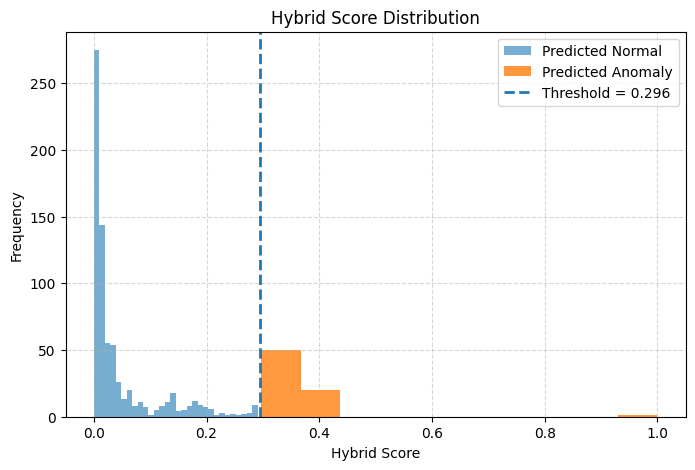

In [26]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================================
# Prepare Test Data for LSTM
# ==========================================================

X_test_seq = np.reshape(
    X_test_tabular,
    (X_test_tabular.shape[0], 1, X_test_tabular.shape[1])
)

# ==========================================================
# LSTM Reconstruction Error
# ==========================================================

X_test_pred = model.predict(X_test_seq)

reconstruction_error = np.mean(
    np.square(X_test_seq - X_test_pred),
    axis=(1, 2)
)

# ==========================================================
# Isolation Forest Anomaly Score
# ==========================================================

if_anomaly_score = 0.5 - test_if_scores

# ==========================================================
# Normalize Scores
# ==========================================================

scaler = MinMaxScaler()

lstm_score_scaled = scaler.fit_transform(
    reconstruction_error.reshape(-1, 1)
).flatten()

if_score_scaled = scaler.fit_transform(
    if_anomaly_score.reshape(-1, 1)
).flatten()

# ==========================================================
# Generate Predictions
# ==========================================================

lstm_threshold = reconstruction_error.mean() + 2 * reconstruction_error.std()
y_pred_lstm = np.where(reconstruction_error > lstm_threshold, 1, 0)

y_pred_if = np.where(test_if_predictions == -1, 1, 0)

alpha = 0.5
hybrid_score = (alpha * lstm_score_scaled) + ((1 - alpha) * if_score_scaled)

hybrid_threshold = hybrid_score.mean() + 2 * hybrid_score.std()
y_pred_hybrid = np.where(hybrid_score > hybrid_threshold, 1, 0)

# Ground truth from pseudo-labels
y_true = y_test.values

# ==========================================================
# Evaluation Function
# ==========================================================

def evaluate_model(name, y_true, y_pred, scores):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    auc = roc_auc_score(y_true, scores)

    return {
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "FPR": fpr,
        "AUC-ROC": auc,
        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    }

# ==========================================================
# Compile Results
# ==========================================================

results = [
    evaluate_model("LSTM Autoencoder", y_true, y_pred_lstm, reconstruction_error),
    evaluate_model("Isolation Forest", y_true, y_pred_if, if_anomaly_score),
    evaluate_model("Hybrid Model", y_true, y_pred_hybrid, hybrid_score)
]

results_df = pd.DataFrame(results)

print("=" * 60)
print("FINAL MODEL EVALUATION RESULTS")
print("=" * 60)

display(results_df.round(4))

# ==========================================================
# Hybrid Results Table
# ==========================================================

hybrid_results = pd.DataFrame({
    "true_label": y_true,
    "lstm_reconstruction_error": reconstruction_error,
    "isolation_forest_score": if_anomaly_score,
    "hybrid_score": hybrid_score,
    "hybrid_prediction": y_pred_hybrid
})

print("\nHybrid Prediction Distribution:")
print(hybrid_results["hybrid_prediction"].value_counts())

print("\nTop 10 Suspicious Users:")
display(
    hybrid_results.sort_values(
        by="hybrid_score",
        ascending=False
    ).head(10)
)

# ==========================================================
# Plot: Hybrid Score Distribution
# ==========================================================

plt.figure(figsize=(8, 5))

plt.hist(
    hybrid_score[y_pred_hybrid == 0],
    bins=30,
    alpha=0.6,
    label="Predicted Normal"
)

plt.hist(
    hybrid_score[y_pred_hybrid == 1],
    bins=10,
    alpha=0.8,
    label="Predicted Anomaly"
)

plt.axvline(
    hybrid_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Threshold = {hybrid_threshold:.3f}"
)

plt.xlabel("Hybrid Score")
plt.ylabel("Frequency")
plt.title("Hybrid Score Distribution")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

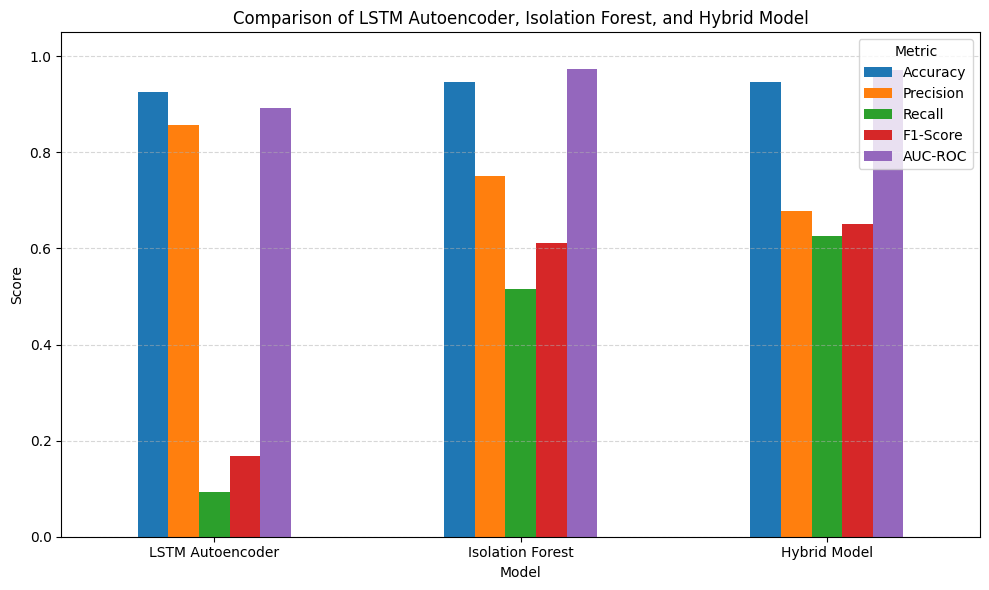

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Results from your evaluation table
model_results = pd.DataFrame({
    "Model": [
        "LSTM Autoencoder",
        "Isolation Forest",
        "Hybrid Model"
    ],
    "Accuracy": [0.9262, 0.9475, 0.9462],
    "Precision": [0.8571, 0.7500, 0.6780],
    "Recall": [0.0938, 0.5156, 0.6250],
    "F1-Score": [0.1690, 0.6111, 0.6504],
    "AUC-ROC": [0.8931, 0.9735, 0.9722]
})

# Bar chart
ax = model_results.set_index("Model").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Comparison of LSTM Autoencoder, Isolation Forest, and Hybrid Model")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

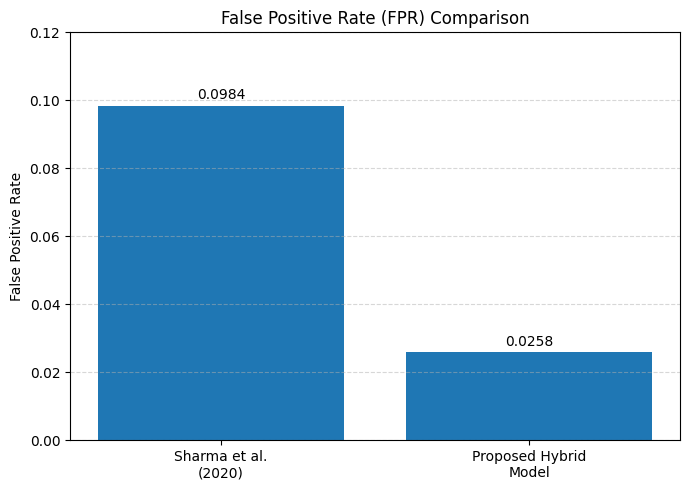

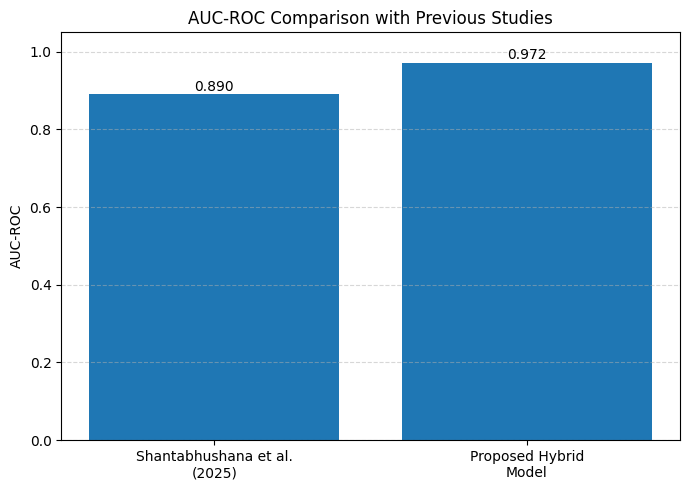

In [28]:
import matplotlib.pyplot as plt


models = [
    "Sharma et al.\n(2020)",
    "Proposed Hybrid\nModel"
]

fpr_values = [
    0.0984,
    0.0258
]

plt.figure(figsize=(7,5))

bars = plt.bar(models, fpr_values)

plt.title("False Positive Rate (FPR) Comparison")
plt.ylabel("False Positive Rate")
plt.ylim(0, 0.12)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.002,
        f"{height:.4f}",
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

studies = [
    "Shantabhushana et al.\n(2025)",
    "Proposed Hybrid\nModel"
]

auc_scores = [
    0.89,
    0.9722
]

plt.figure(figsize=(7,5))

bars = plt.bar(studies, auc_scores)

plt.title("AUC-ROC Comparison with Previous Studies")
plt.ylabel("AUC-ROC")
plt.ylim(0, 1.05)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.3f}",
        ha="center"
    )

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

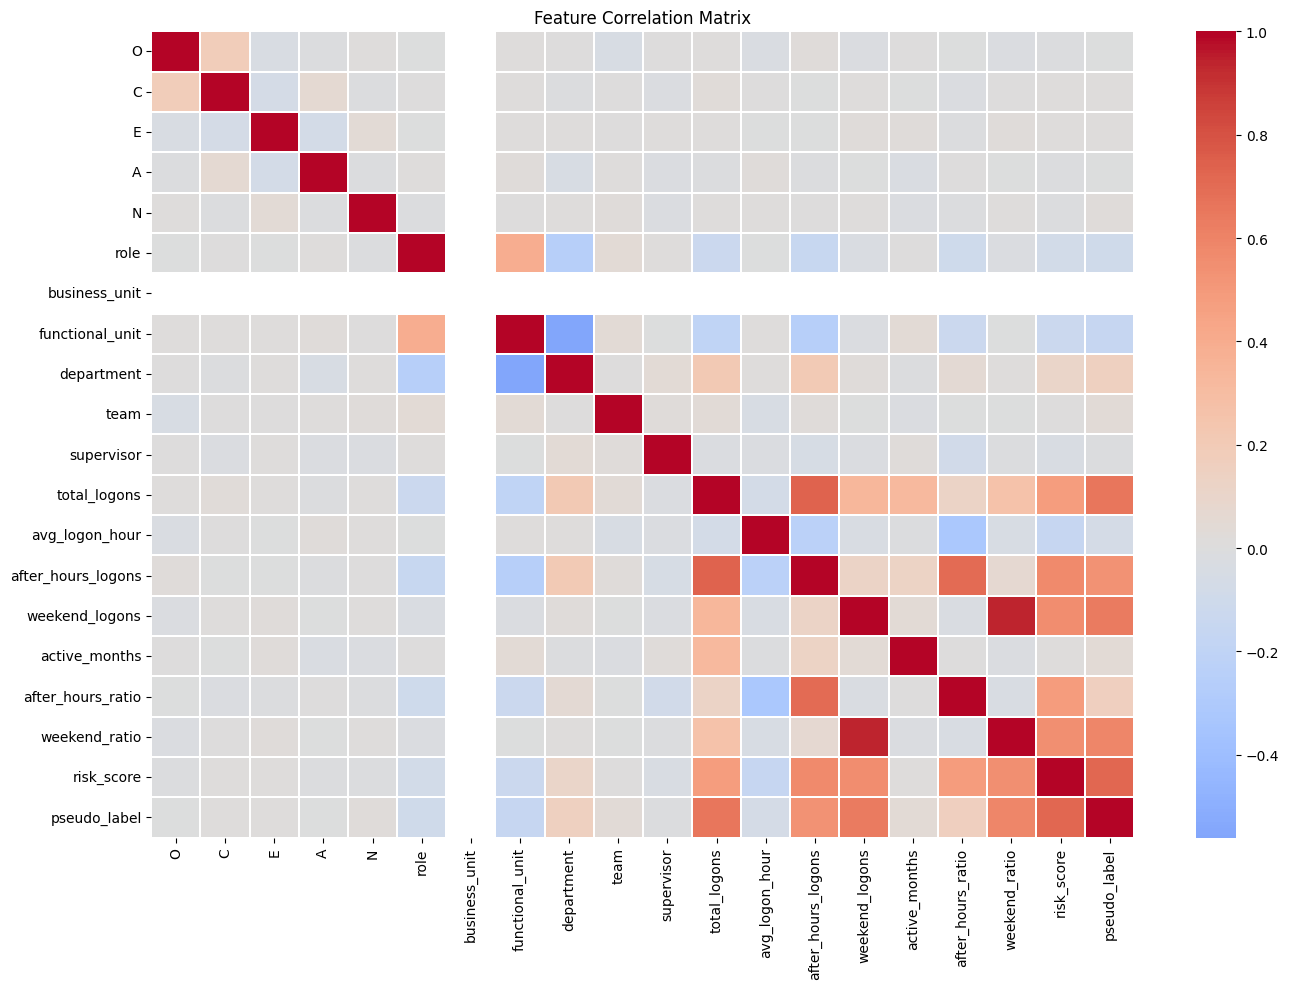

Correlation of each feature with pseudo_label:
risk_score            0.722137
total_logons          0.664014
weekend_logons        0.637032
weekend_ratio         0.587280
after_hours_logons    0.536396
after_hours_ratio     0.161220
functional_unit       0.154800
department            0.152259
role                  0.094707
avg_logon_hour        0.062378
active_months         0.048415
team                  0.031773
N                     0.018664
C                     0.014830
E                     0.012784
supervisor            0.006598
A                     0.004126
O                     0.000148
business_unit              NaN
Name: pseudo_label, dtype: float64

Ranked feature importance based on correlation with pseudo_label:
               Feature  Absolute_Correlation_with_Pseudo_Label
0           risk_score                                0.722137
1         total_logons                                0.664014
2       weekend_logons                                0.637032
3        w

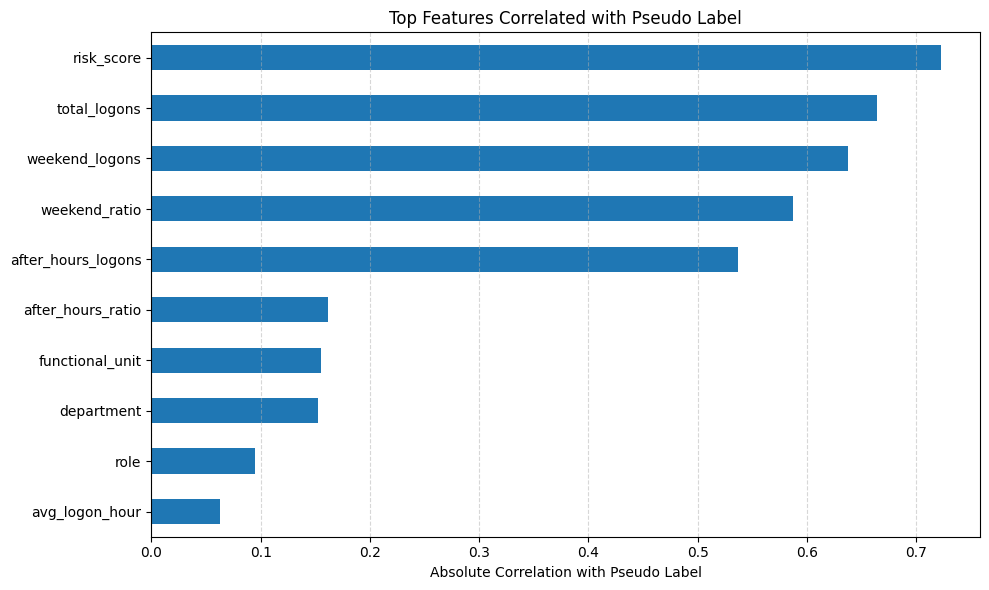

In [29]:
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

# ==========================================================

# CORRELATION MATRIX + CORRELATION WITH PSEUDO LABEL

# ==========================================================

# Ensure pseudo_label exists

if "pseudo_label" not in pseudo_data.columns:

    raise ValueError("pseudo_label column not found in pseudo_data")

# Keep only numeric columns for correlation analysis

numeric_df = pseudo_data.select_dtypes(include=[np.number]).copy()

# ----------------------------------------------------------

# 1) Correlation matrix of all numeric features

# ----------------------------------------------------------

corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))

sns.heatmap(

    corr_matrix,

    cmap="coolwarm",

    center=0,

    linewidths=0.3,

    annot=False

)

plt.title("Feature Correlation Matrix")

plt.tight_layout()

plt.show()

# ----------------------------------------------------------

# 2) Correlation of each feature with pseudo_label

# ----------------------------------------------------------

corr_with_label = corr_matrix["pseudo_label"].drop("pseudo_label")

corr_with_label = corr_with_label.abs().sort_values(ascending=False)

print("Correlation of each feature with pseudo_label:")

print(corr_with_label)

# Convert to table for report

corr_table = corr_with_label.reset_index()

corr_table.columns = ["Feature", "Absolute_Correlation_with_Pseudo_Label"]

print("\nRanked feature importance based on correlation with pseudo_label:")

print(corr_table)

# Save results if needed

corr_table.to_csv("feature_correlation_with_pseudo_label.csv", index=False)

# ----------------------------------------------------------

# 3) Bar chart of top correlated features

# ----------------------------------------------------------

plt.figure(figsize=(10, 6))

corr_with_label.head(10).sort_values().plot(kind="barh")

plt.xlabel("Absolute Correlation with Pseudo Label")

plt.title("Top Features Correlated with Pseudo Label")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

[[722  15]
 [  7  56]]


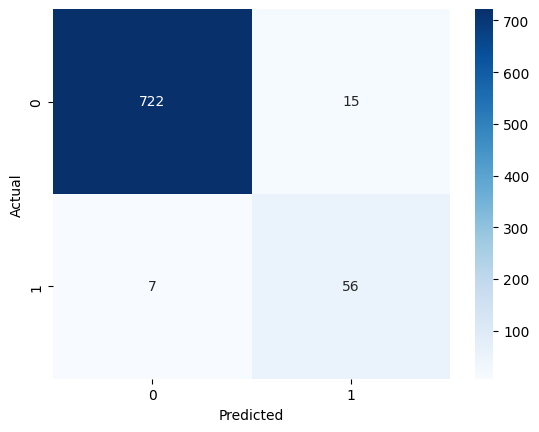

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_hybrid)
print(cm)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

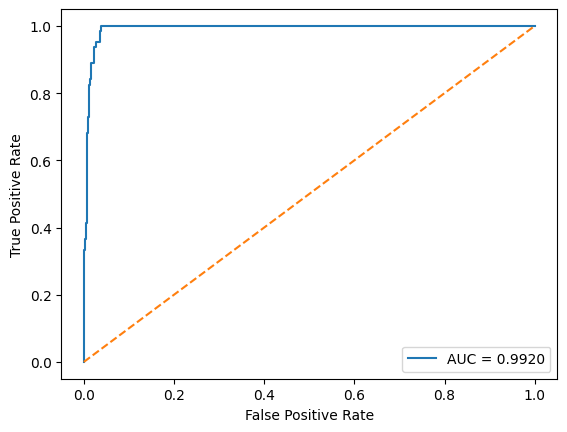

In [32]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, hybrid_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()